In [2]:
import numpy as np
import scanpy
import phate
import scprep
import matplotlib.pyplot as plt
import magic
import leidenalg
import seaborn as sns
from sklearn.preprocessing import scale
import pandas as pd
import meld
from collections import defaultdict
import scipy

/home/aarthivenkat/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [4]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

In [4]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 39704 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 18.21 seconds.
    Calculating KNN search...
    Calculated KNN search in 48.83 seconds.
    Calculating affinities...
    Calculated affinities in 6.12 seconds.
  Calculated graph and diffusion operator in 73.71 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 19.44 seconds.
    Calculating KMeans...
    Calculated KMeans in 9.65 seconds.
  Calculated landmark operator in 31.07 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 1.63 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.36 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.65 seconds.
Calculated PHATE in 112.44 seconds.


In [5]:
gene_embedding_results = np.load('results/GSPA_QR_without_regression.npz', allow_pickle=True)

In [6]:
data_ae = gene_embedding_results['signal_embedding']
localization = gene_embedding_results['localization_score']
hvgs = gene_embedding_results['genes']

In [7]:
magic_op = magic.MAGIC()
data_magic = magic_op.fit_transform(adata.to_df(), genes=hvgs, graph=phate_op.graph)

Calculating MAGIC...
  Running MAGIC on 39704 cells and 14152 genes.
  Using precomputed graph and diffusion operator...


/home/aarthivenkat/.local/lib/python3.8/site-packages/magic/magic.py:425: UserWarning: Input matrix contains unexpressed genes. Please remove them prior to running MAGIC.
  warnings.warn(


  Calculating imputation...
  Calculated imputation in 19.48 seconds.
Calculated MAGIC in 20.73 seconds.


In [8]:
cmap = dict([(sample,plt.cm.Paired.colors[:6][i]) for i,sample in enumerate(['AcuteD4', 'ChronicD4', 'AcuteD8', 'ChronicD8', 'Acute40', 'Chronic40'])])

In [9]:
markers = {'Proliferation':["Mki67", 'Birc5', 'Pclaf', 'Top2a', 'Hist1h1b', 'Stmn1'],
           'Naive and Stem-like': ["Tcf7", "Lef1", "Ccr7", "Sell", "Ltb", "Gpr183", 'Xcl1', 'Slamf6'],
           'Ifn-signaling': ["Irf7", "Stat1", 'Isg20', 'Ifit1', 'Ifit3', 'Isg15'],
           'Effector': ["Nkg7", "Ccl5", "Ly6c2", "Lgals1", "Prf1", "Klrg1", "Cx3cr1", "Klre1", "Zeb2", "Gzma", "Gzmb", "Klf2", "S1pr5"],
           'Exhaustion': ['Pdcd1', 'Ctla4', 'Lag3', 'Tox'],
           'Effector Memory': ['Tnf', 'Il7r', 'Cd69']}

In [10]:
gene_phate_op = phate.PHATE(random_state=0)
data_phate = gene_phate_op.fit_transform(data_ae)

Calculating PHATE...
  Running PHATE on 1416 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.19 seconds.
    Calculating affinities...
    Calculated affinities in 0.02 seconds.
  Calculated graph and diffusion operator in 0.24 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 0.75 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.16 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.73 seconds.
Calculated PHATE in 2.89 seconds.


<AxesSubplot:title={'center':'Gene localization'}, xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

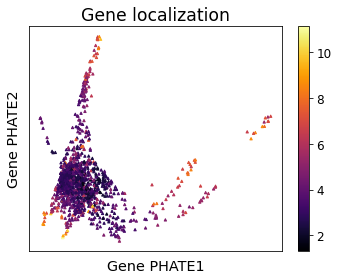

In [74]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c=localization, dpi=200, filename='figures/localization.png',
                          title='Gene localization', label_prefix='Gene PHATE', legend_loc=(1.05,0), marker='^')

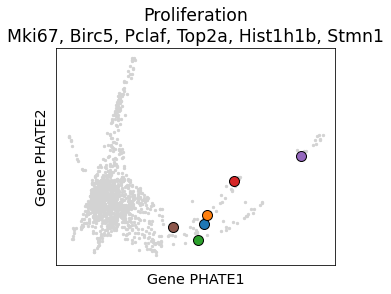

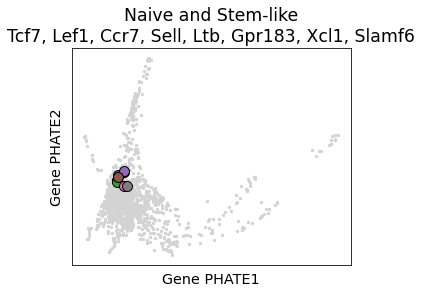

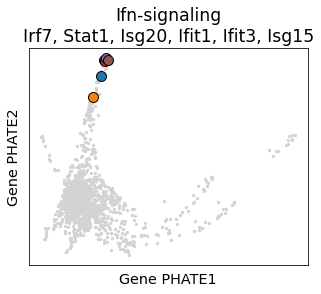

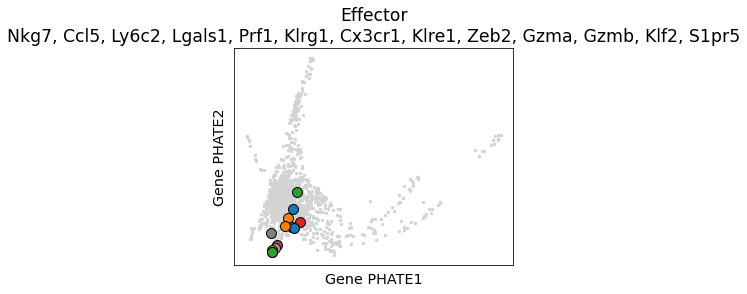

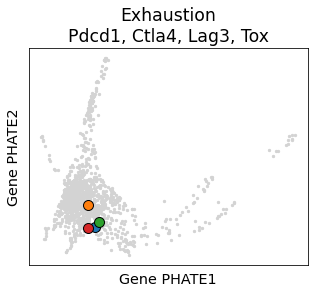

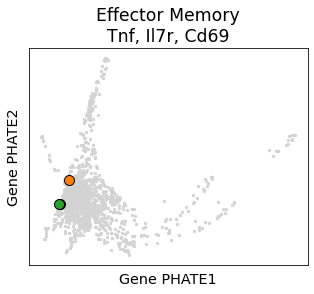

In [12]:
for name,genes in markers.items():
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c='lightgray', ax=ax,
                          title=f'{name}\n{", ".join(genes)}', label_prefix='Gene PHATE')
    for gene in genes:
        scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), mask=hvgs == gene,
                              s=100, ax=ax, edgecolor='black')

In [13]:
gene_clusters = np.array(leidenalg.find_partition(gene_phate_op.graph.to_igraph(), 
                                                  leidenalg.ModularityVertexPartition,
                                                  seed=0).membership)
gene_clusters = pd.Series(gene_clusters, index=hvgs)

<AxesSubplot:title={'center':'Gene clusters'}, xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

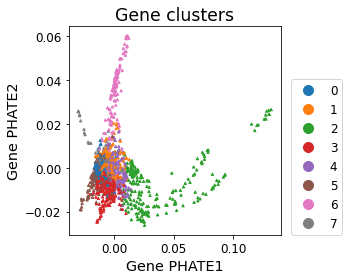

In [14]:
scprep.plot.scatter2d(data_phate, ticks=True, figsize=(5,4), c=gene_clusters, dpi=200, filename='figures/gene_clusters.png',
                          title='Gene clusters', label_prefix='Gene PHATE', legend_loc=(1.05,0), marker='^')

In [16]:
conv = {0:0, 1:1, 2:2, 3:3, 4:4, 5:0, 6:5, 7:1}

In [17]:
gene_clusters = [conv[x] for x in gene_clusters]
gene_clusters = pd.Series(gene_clusters, index=hvgs)

<AxesSubplot:title={'center':'Gene clusters'}, xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

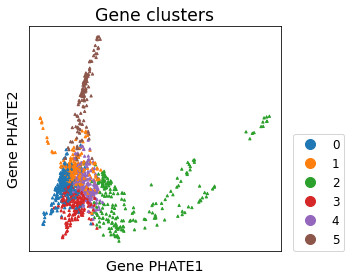

In [18]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c=gene_clusters, dpi=200, filename='figures/gene_clusters.png',
                          title='Gene clusters', label_prefix='Gene PHATE', legend_loc=(1.05,0), marker='^')

In [19]:
for name, genes in markers.items():
    print (name, pd.Series(gene_clusters, index=hvgs).loc[genes])

Proliferation Mki67       2
Birc5       2
Pclaf       2
Top2a       2
Hist1h1b    2
Stmn1       2
dtype: int64
Naive and Stem-like Tcf7      1
Lef1      1
Ccr7      1
Sell      1
Ltb       4
Gpr183    1
Xcl1      1
Slamf6    4
dtype: int64
Ifn-signaling Irf7     5
Stat1    5
Isg20    5
Ifit1    5
Ifit3    5
Isg15    5
dtype: int64
Effector Nkg7      3
Ccl5      3
Ly6c2     4
Lgals1    3
Prf1      3
Klrg1     3
Cx3cr1    3
Klre1     3
Zeb2      3
Gzma      3
Gzmb      3
Klf2      3
S1pr5     3
dtype: int64
Exhaustion Pdcd1    4
Ctla4    4
Lag3     4
Tox      3
dtype: int64
Effector Memory Tnf     0
Il7r    0
Cd69    0
dtype: int64


In [20]:
localization = pd.Series(localization, index=hvgs)
gene_summary = pd.concat((gene_clusters, localization), axis=1)
gene_summary.columns = ['gene_clusters', 'localization_score']

In [16]:
gene_summary = pd.read_csv('results/gene_summary.csv', index_col=0).set_index('Unnamed: 0')
hvgs=gene_summary.index.values

In [18]:
for module in range(gene_summary['gene_clusters'].max() + 1):
    gene_list = gene_summary[(gene_summary['gene_clusters'] == module)].index
    
    scanpy.tl.score_genes(adata, gene_list=gene_list,
                          random_state=0, score_name=f'GM_{module}_score',
                          gene_pool=hvgs, n_bins=int(len(hvgs) * 0.25))

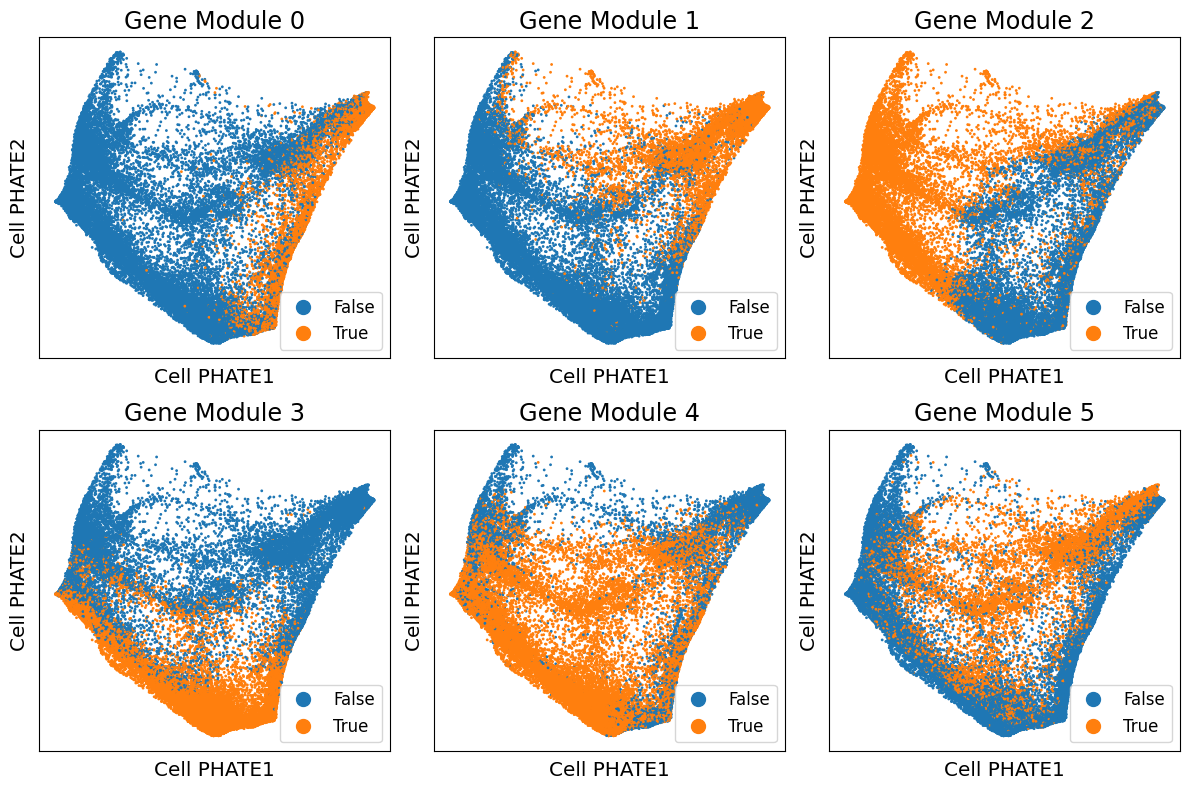

In [21]:
fig, ax = plt.subplots(2,3, figsize=(12,8), dpi=100); ax=ax.flatten()
for clust in range(gene_summary['gene_clusters'].max() + 1):
    scprep.plot.scatter2d(adata.obsm['X_phate'], ax=ax[clust],
                          c=adata.obs[f'GM_{clust}_score'] > 0.0,
                          title=f'Gene Module {clust}', ticks=None, label_prefix='Cell PHATE')

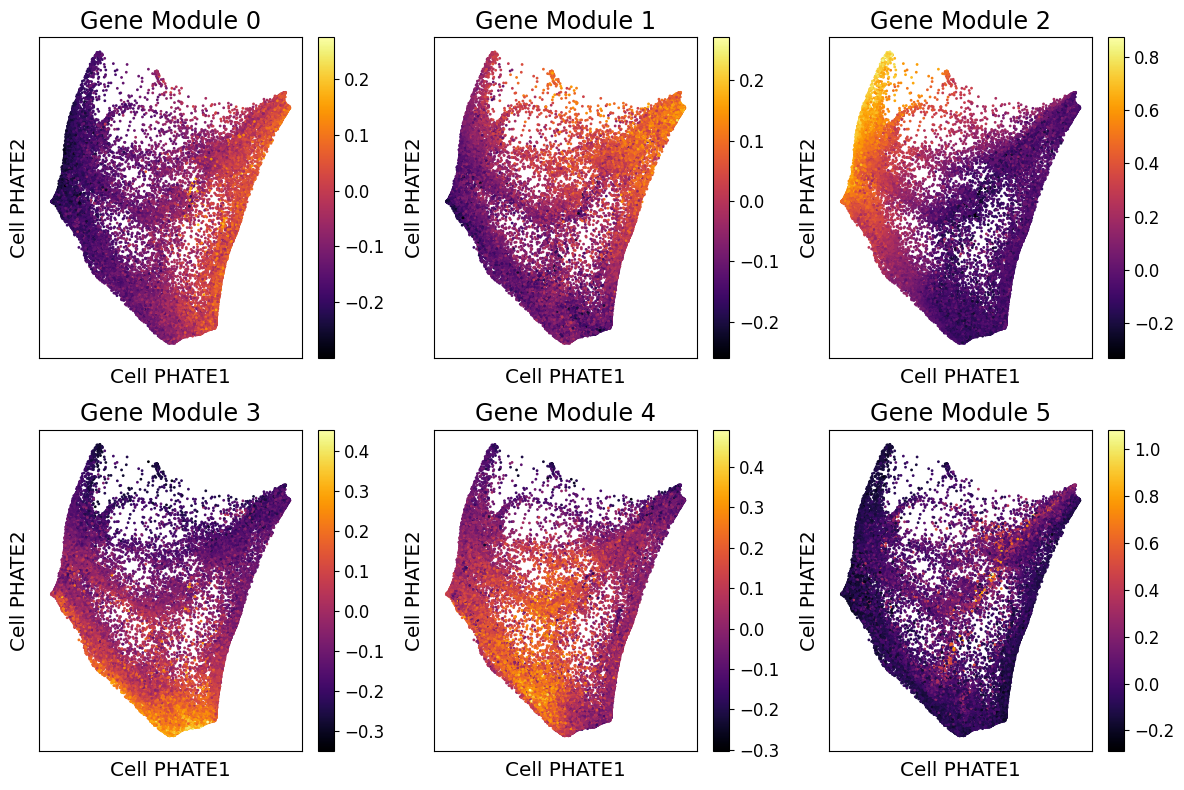

In [22]:
fig, ax = plt.subplots(2,3, figsize=(12,8), dpi=100); ax=ax.flatten()
for clust in range(gene_summmary['gene_clusters'].max() + 1):
    scprep.plot.scatter2d(adata.obsm['X_phate'], ax=ax[clust],
                          c=adata.obs[f'GM_{clust}_score'],
                          title=f'Gene Module {clust}', ticks=None, label_prefix='Cell PHATE')

plt.tight_layout()
fig.savefig('figures/gene_cluster_mean_expression.png', dpi=200)

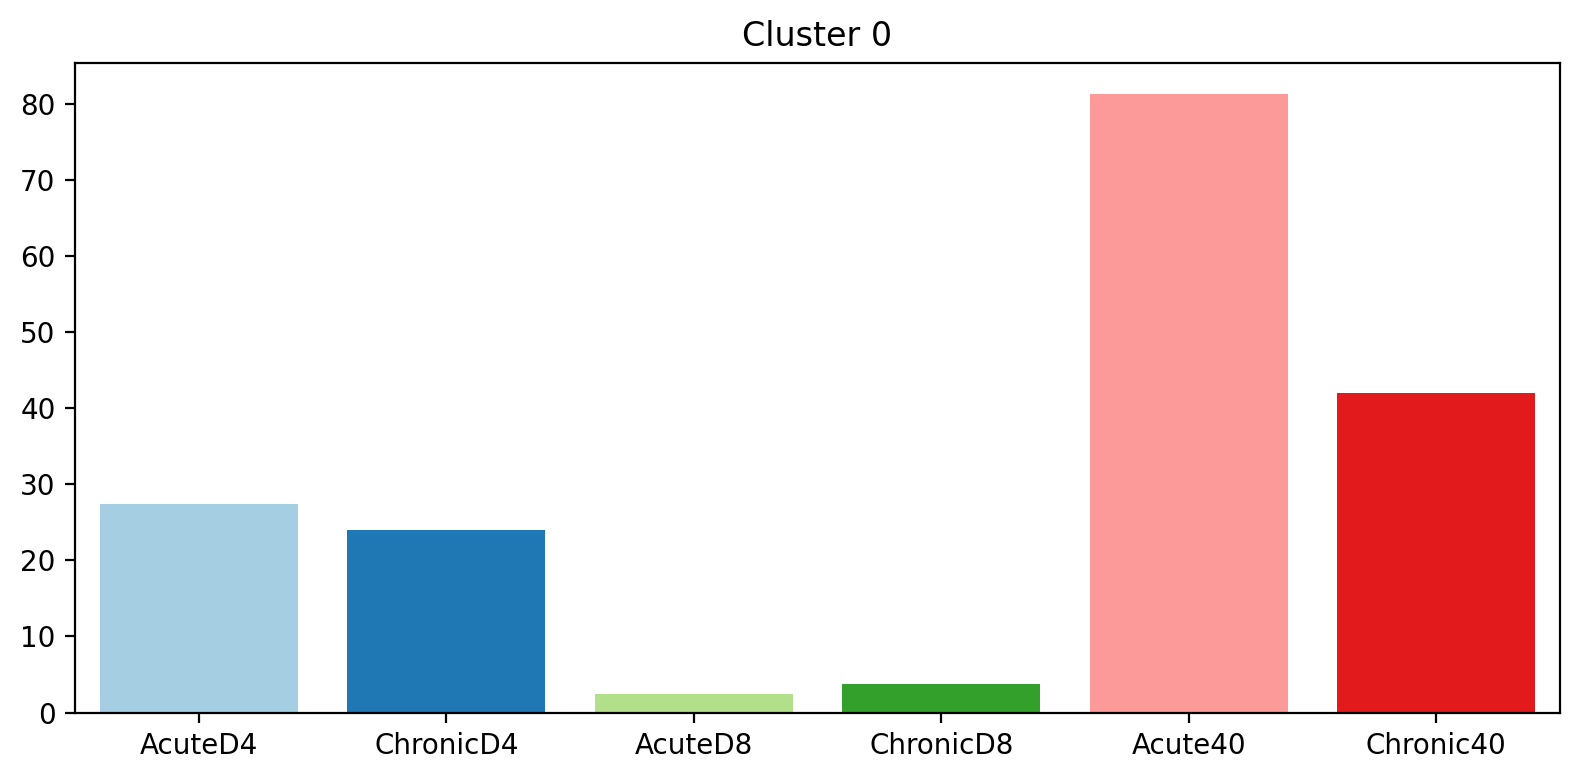

<Figure size 432x288 with 0 Axes>

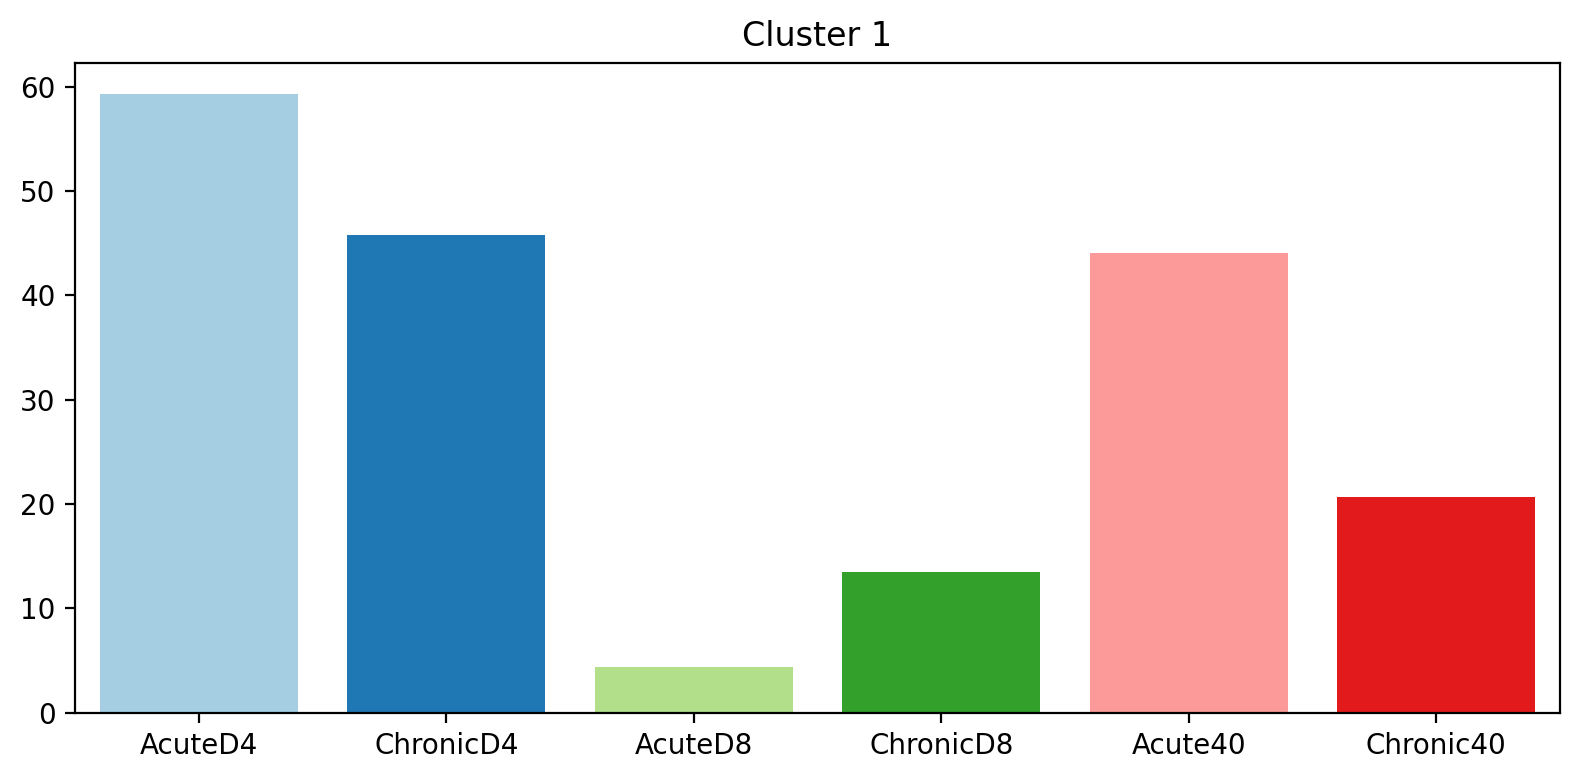

<Figure size 432x288 with 0 Axes>

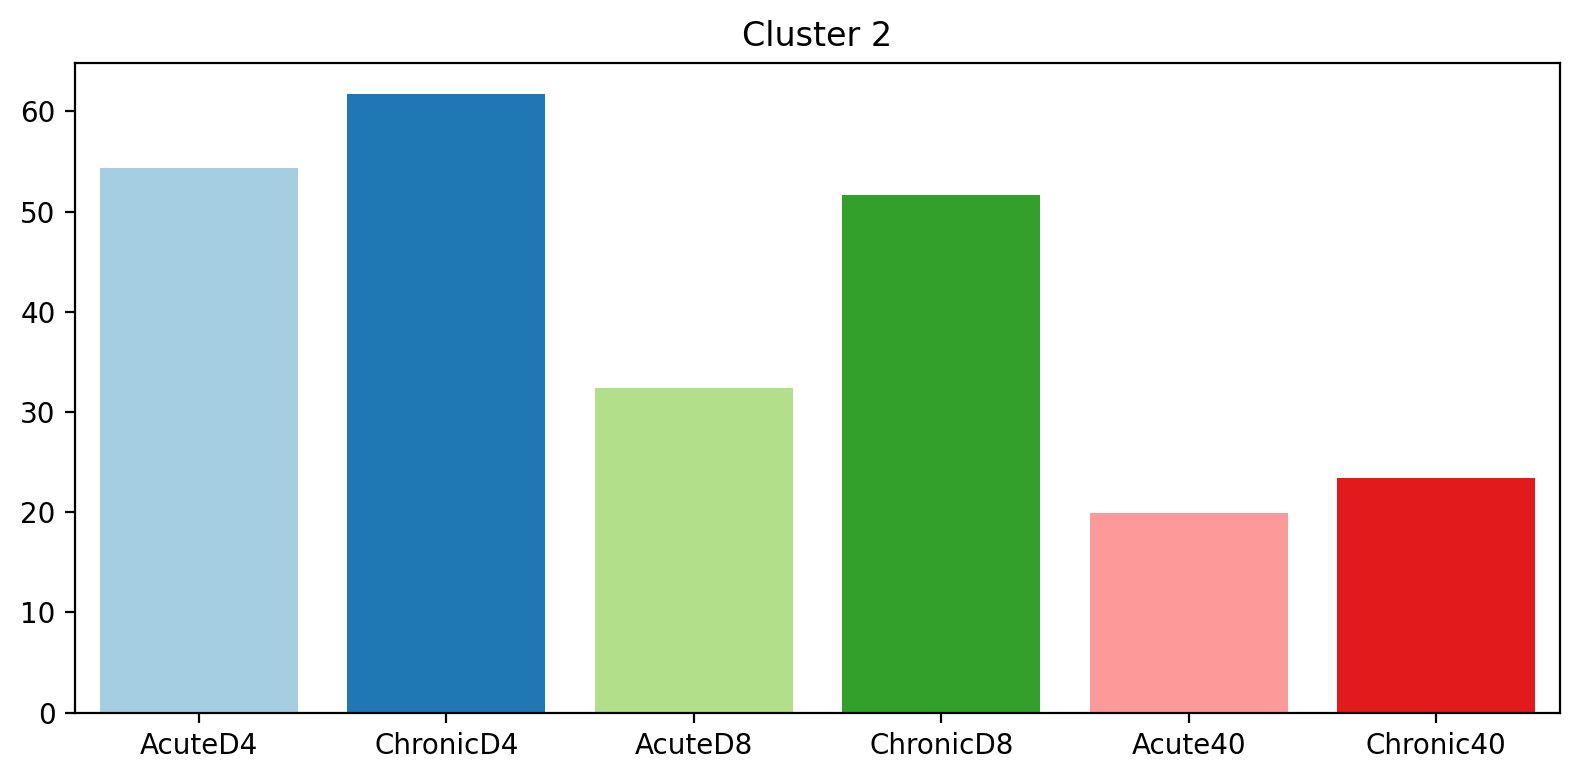

<Figure size 432x288 with 0 Axes>

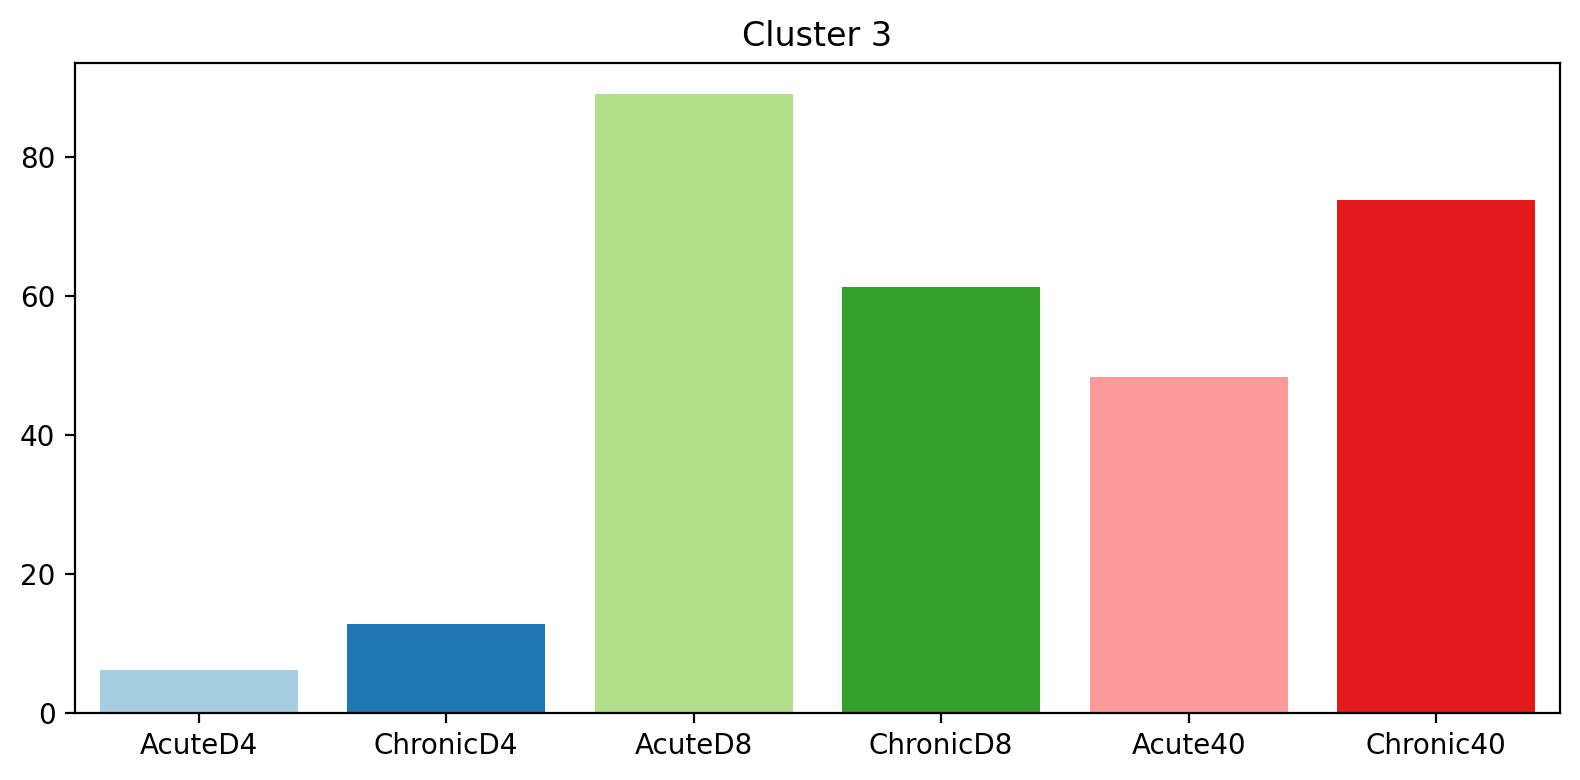

<Figure size 432x288 with 0 Axes>

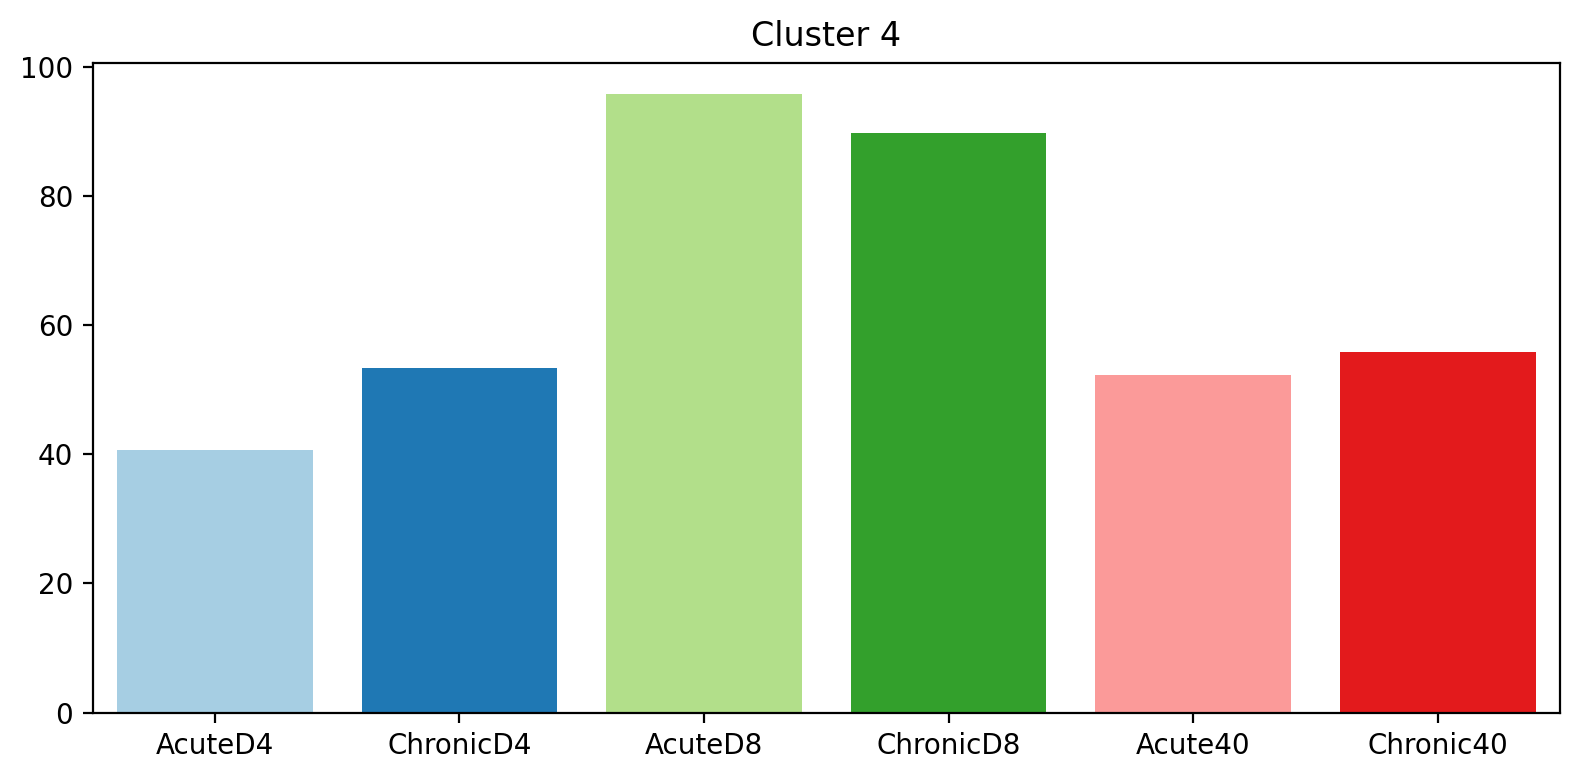

<Figure size 432x288 with 0 Axes>

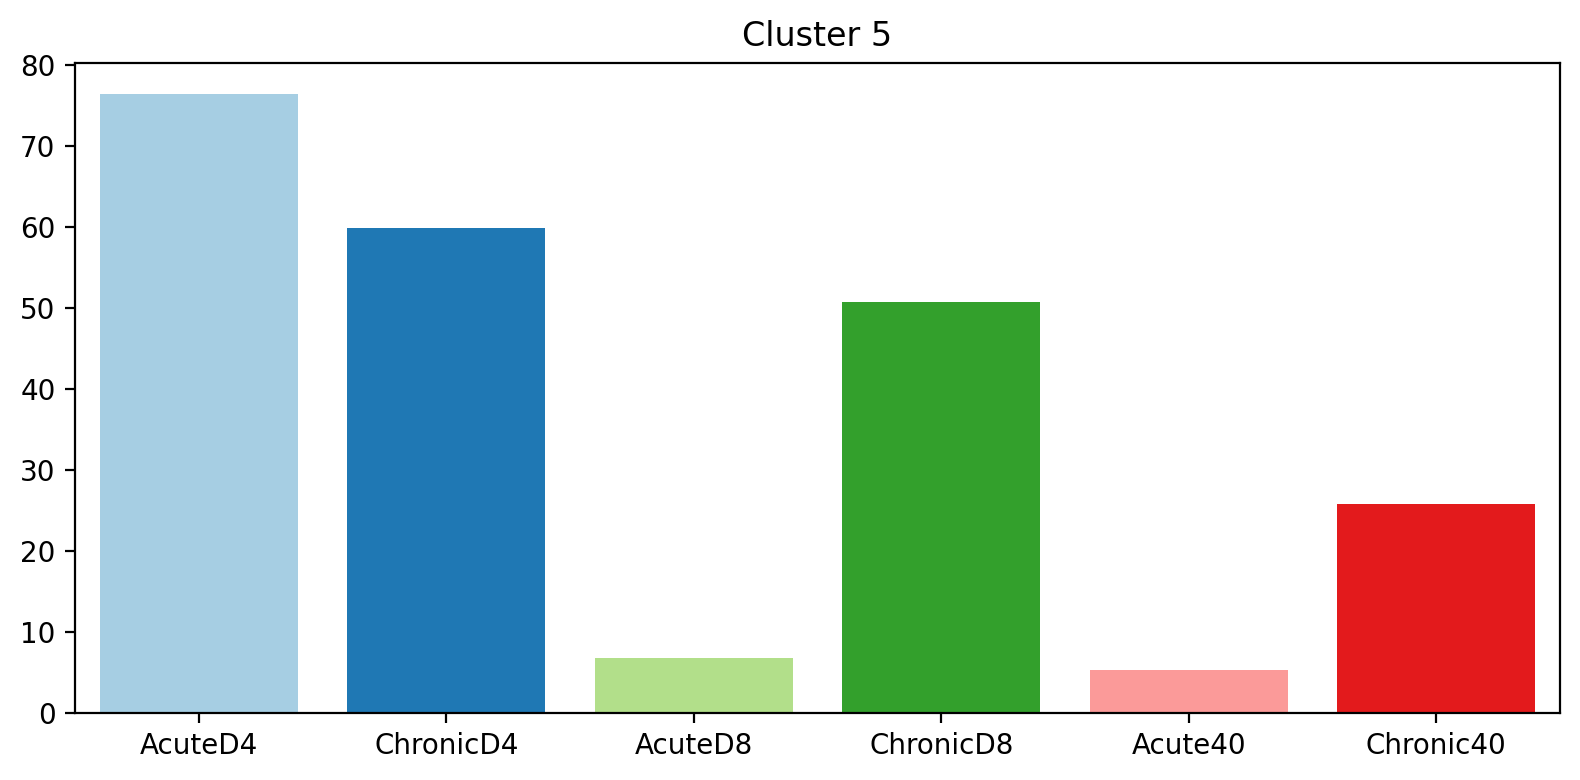

<Figure size 432x288 with 0 Axes>

In [77]:
for clust in range(gene_clusters.max() + 1):
    df = 100* adata.obs['batch'][adata.obs[f'GM_{clust}_score'] > 0.0].value_counts() / adata.obs['batch'].value_counts()
    df = df.loc[cmap.keys()]
    
    fig = plt.figure(figsize=(8,4), dpi=200)
    ax = sns.barplot(x=list(df.index), y=df.values)
    
    for i,name in enumerate(cmap.keys()):
        ax.patches[i].set_facecolor(cmap[name])
    
    plt.title(f'Cluster {clust}')
    plt.tight_layout()
    fig.savefig(f'figures/gene_cluster_{clust}_sample_proportion.png', dpi=200)
    plt.show(); plt.clf()

In [78]:
gene_summary.to_csv('results/gene_summary.csv')